In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/imoveis_consolidado.csv")

print(f"Total: {len(df)}")
print(f"Bairros: {df['bairro'].nunique()}")
print(f"Com área: {df['area'].notna().sum()}")

# Preço por m²
df['preco_m2'] = df['preco'] / df['area']

# Corte de amostra mínima
MIN_AMOSTRA = 20
contagem = df['bairro'].value_counts()
bairros_validos = contagem[contagem >= MIN_AMOSTRA].index
df_analise = df[df['bairro'].isin(bairros_validos)]

print(f"\nBairros com n>={MIN_AMOSTRA}: {len(bairros_validos)}")
print(f"Imóveis nesses bairros: {len(df_analise)} ({len(df_analise)/len(df)*100:.1f}% da amostra)")

Total: 1357
Bairros: 63
Com área: 1167

Bairros com n>=20: 17
Imóveis nesses bairros: 1058 (78.0% da amostra)


In [3]:
resumo = df_analise.groupby('bairro').agg(
    n=('preco', 'size'),
    preco_mediano=('preco', 'median'),
    preco_m2_mediano=('preco_m2', 'median'),
    n_com_area=('area', 'count')
).round(2)

# Ranking em cada métrica
resumo['rank_preco'] = resumo['preco_mediano'].rank(ascending=False).astype(int)
resumo['rank_preco_m2'] = resumo['preco_m2_mediano'].rank(ascending=False).astype(int)
resumo['divergencia'] = resumo['rank_preco'] - resumo['rank_preco_m2']

print("=== Bairros ordenados por divergência de ranking ===")
print("(positivo = caro no total, barato por m² → imóveis grandes)")
print("(negativo = barato no total, caro por m² → imóveis pequenos/adensados)\n")
print(resumo.sort_values('divergencia', ascending=False)[
    ['n', 'preco_mediano', 'preco_m2_mediano', 'rank_preco', 'rank_preco_m2', 'divergencia']
])

=== Bairros ordenados por divergência de ranking ===
(positivo = caro no total, barato por m² → imóveis grandes)
(negativo = barato no total, caro por m² → imóveis pequenos/adensados)

                        n  preco_mediano  preco_m2_mediano  rank_preco  \
bairro                                                                   
Vila Moco              38       400000.0           5456.25          12   
Antonio Cassimiro      51       250000.0           3604.63          16   
Atras Da Banca         45       700000.0           7634.03           5   
Jatoba                 50       375000.0           4207.08          13   
Topazio                21       250000.0           3483.15          16   
Vila Eduardo           49       630000.0           6262.02           8   
Boa Esperanca          88      1625000.0           7857.14           1   
Dom Avelar             76       300000.0           2666.46          15   
Cidade Universitaria   41      1200000.0           6349.21           3   
J

In [4]:
dispersao = df_analise.groupby('bairro').agg(
    n=('preco', 'size'),
    mediana=('preco', 'median'),
    q1=('preco', lambda x: x.quantile(0.25)),
    q3=('preco', lambda x: x.quantile(0.75)),
).round(2)

dispersao['iqr'] = dispersao['q3'] - dispersao['q1']
# IQR relativo: dispersão proporcional à mediana, comparável entre bairros de faixas diferentes
dispersao['iqr_relativo'] = (dispersao['iqr'] / dispersao['mediana']).round(2)

print("=== Dispersão de preço por bairro ===")
print("(iqr_relativo alto = mercado heterogêneo, mais margem de negociação)\n")
print(dispersao.sort_values('iqr_relativo', ascending=False))

=== Dispersão de preço por bairro ===
(iqr_relativo alto = mercado heterogêneo, mais margem de negociação)

                        n    mediana         q1         q3        iqr  \
bairro                                                                  
Fernando Idalino       37  1350000.0   318900.0  2050000.0  1731100.0   
Loteamento Recife     147   650000.0   350000.0  1150000.0   800000.0   
Sao Jose               37   650000.0   410000.0  1200000.0   790000.0   
Vila Eduardo           49   630000.0   480000.0  1200000.0   720000.0   
Centro                213  1100000.0   550000.0  1800000.0  1250000.0   
Caminho Do Sol         31   550000.0   520000.0  1145000.0   625000.0   
Vila Moco              38   400000.0   335000.0   790000.0   455000.0   
Jatoba                 50   375000.0   303000.0   720000.0   417000.0   
Topazio                21   250000.0   240000.0   480000.0   240000.0   
Joao De Deus           34   357500.0   238750.0   545000.0   306250.0   
Boa Esperanca   

In [5]:
# Primeiro: onde as duas fontes têm amostra suficiente?
cruzamento = df.groupby(['bairro', 'fonte']).size().unstack(fill_value=0)
cruzamento.columns.name = None

MIN_POR_FONTE = 5
comparaveis = cruzamento[
    (cruzamento.get('OLX', 0) >= MIN_POR_FONTE) &
    (cruzamento.get('A7 Imobiliaria', 0) >= MIN_POR_FONTE)
]

print(f"Bairros com pelo menos {MIN_POR_FONTE} imóveis de CADA fonte: {len(comparaveis)}\n")
print(comparaveis)

if len(comparaveis) > 0:
    df_comp = df[df['bairro'].isin(comparaveis.index)]
    tabela = df_comp.groupby(['bairro', 'fonte'])['preco'].median().unstack()
    tabela['diferenca_%'] = ((tabela['A7 Imobiliaria'] / tabela['OLX'] - 1) * 100).round(1)
    print("\n=== Preço mediano por fonte ===")
    print(tabela.round(2))
else:
    print("Nenhum bairro tem amostra suficiente das duas fontes para comparação confiável.")

Bairros com pelo menos 5 imóveis de CADA fonte: 5

                      A7 Imobiliaria  OLX
bairro                                   
Antonio Cassimiro                  6   45
Boa Esperanca                     23   65
Centro                             5  208
Cidade Universitaria               7   34
Sao Jose                           6   31

=== Preço mediano por fonte ===
fonte                 A7 Imobiliaria        OLX  diferenca_%
bairro                                                      
Antonio Cassimiro           210000.0   255000.0        -17.6
Boa Esperanca              1400000.0  1700000.0        -17.6
Centro                      530000.0  1100000.0        -51.8
Cidade Universitaria       1000000.0  1200000.0        -16.7
Sao Jose                    542183.5   700000.0        -22.5


In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [7]:
df_comp = df[df['bairro'].isin(['Antonio Cassimiro', 'Boa Esperanca', 'Cidade Universitaria', 'Sao Jose'])]
print(df_comp.groupby(['bairro', 'fonte'])['area'].median())

bairro                fonte         
Antonio Cassimiro     A7 Imobiliaria      57.0
                      OLX                 80.0
Boa Esperanca         A7 Imobiliaria     275.5
                      OLX                200.0
Cidade Universitaria  A7 Imobiliaria     200.0
                      OLX                200.0
Sao Jose              A7 Imobiliaria    1220.0
                      OLX                147.0
Name: area, dtype: float64


In [8]:
tabela_m2 = df_comp.groupby(['bairro', 'fonte'])['preco_m2'].median().unstack()
tabela_m2['diferenca_%'] = ((tabela_m2['A7 Imobiliaria'] / tabela_m2['OLX'] - 1) * 100).round(1)
print(tabela_m2.round(2))

fonte                 A7 Imobiliaria      OLX  diferenca_%
bairro                                                    
Antonio Cassimiro            4875.44  3582.62         36.1
Boa Esperanca                5750.00  8217.38        -30.0
Cidade Universitaria         4860.34  6600.00        -26.4
Sao Jose                     2363.64  4977.38        -52.5


## GRÁFICOS

In [9]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

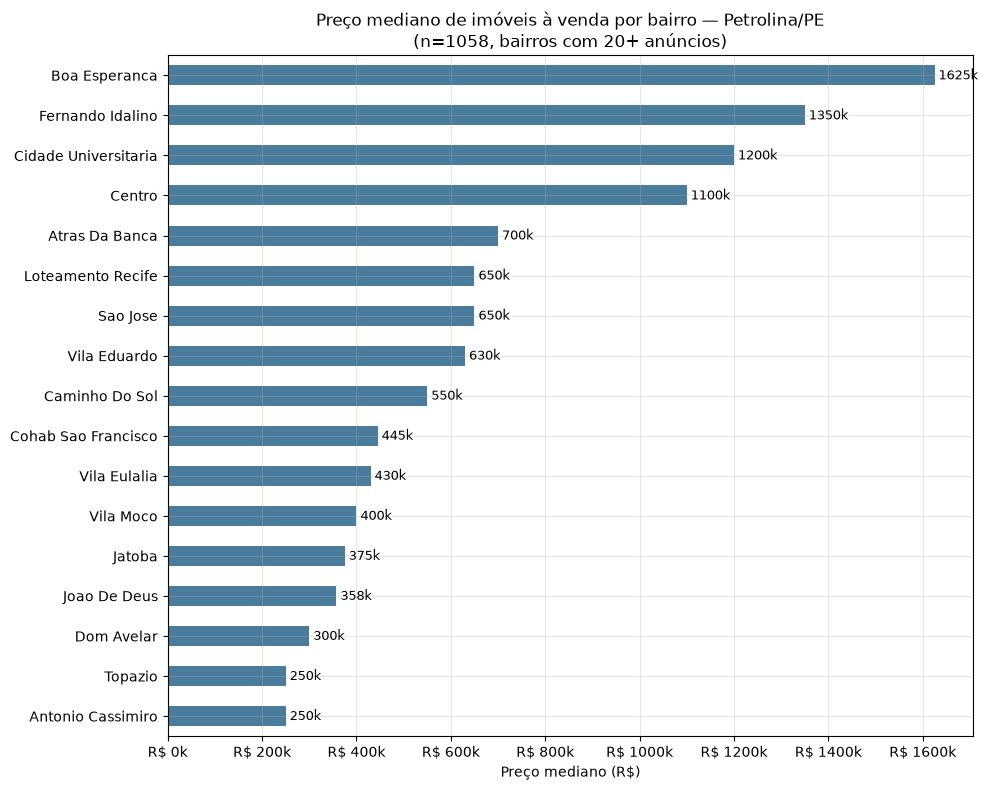

In [21]:
ordem = df_analise.groupby('bairro')['preco'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ordem.plot(kind='barh', ax=ax, color='#4a7c9e')
ax.set_xlabel('Preço mediano (R$)')
ax.set_ylabel('')
ax.set_title(f'Preço mediano de imóveis à venda por bairro — Petrolina/PE\n(n={len(df_analise)}, bairros com 20+ anúncios)')
ax.xaxis.set_major_formatter(lambda x, p: f'R$ {x/1000:.0f}k')

for i, v in enumerate(ordem):
    ax.text(v, i, f' {v/1000:.0f}k', va='center', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_2624\1745128336.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(dados, vert=False, tick_labels=ordem_mediana, showfliers=True,


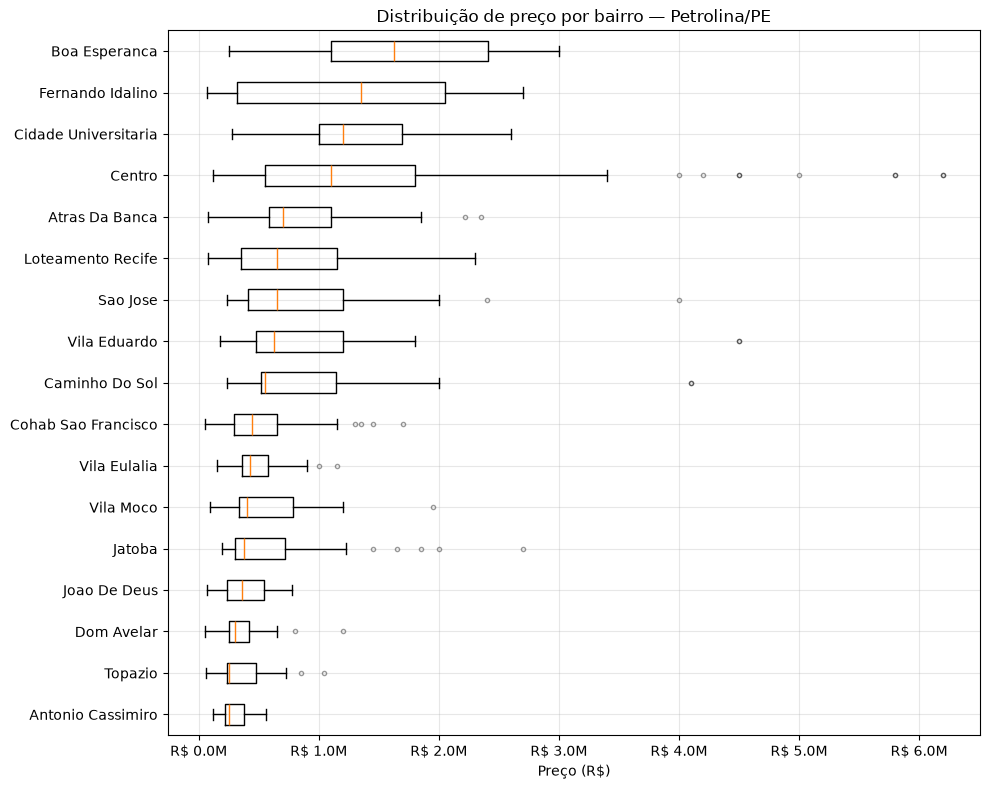

In [20]:
ordem_mediana = df_analise.groupby('bairro')['preco'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 8))
dados = [df_analise[df_analise['bairro'] == b]['preco'].values for b in ordem_mediana]

ax.boxplot(dados, vert=False, tick_labels=ordem_mediana, showfliers=True,
           flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_xlabel('Preço (R$)')
ax.set_title('Distribuição de preço por bairro — Petrolina/PE')
ax.xaxis.set_major_formatter(lambda x, p: f'R$ {x/1_000_000:.1f}M')

plt.tight_layout()
plt.show()

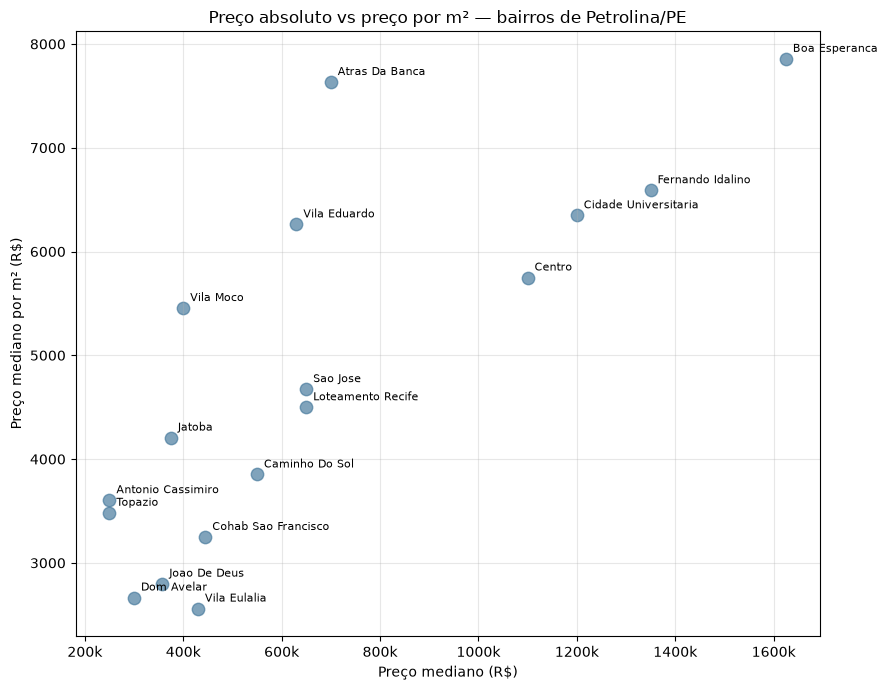

In [19]:
comp = df_analise.groupby('bairro').agg(
    preco=('preco', 'median'),
    preco_m2=('preco_m2', 'median')
).dropna()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(comp['preco'], comp['preco_m2'], s=80, alpha=0.7, color='#4a7c9e')

for bairro, row in comp.iterrows():
    ax.annotate(bairro, (row['preco'], row['preco_m2']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Preço mediano (R$)')
ax.set_ylabel('Preço mediano por m² (R$)')
ax.set_title('Preço absoluto vs preço por m² — bairros de Petrolina/PE')
ax.xaxis.set_major_formatter(lambda x, p: f'{x/1000:.0f}k')

plt.tight_layout()
plt.show()